# Predicting Customer Churn — and What to Do About It

**Business problem.** A subscription telco loses ~27% of its customers each period. Because retention costs far less than acquisition, the goal is a model that **flags at-risk customers early** — plus a clear recommendation on *how aggressively* to act on those flags.

**Dataset.** 7,043 customers × 21 attributes (contract, tenure, services, billing). Target: `Churn` (Yes / No).

**Headline results**
- **Who churns:** month-to-month contracts (**43%**), electronic-check payers (**45%**), and fiber-optic internet (**42%**) are the highest-risk segments; two-year contracts barely churn (3%).
- **Catching churners:** a class-balanced model flags **~80%** of churners, vs. just 56% for a default logistic model — at the cost of more false alarms.
- **The real lever is the decision threshold, not the algorithm.** The strong models *rank* churners similarly (AUC ≈ 0.82–0.85; a single unpruned tree is the exception at 0.66). Where you draw the "flag as churn" line is a **business** call — moving it from the naive 0.50 to the value-maximizing 0.14 is worth **~$26K** of expected net value on the 2,113-customer test set (at $200 / save, $20 / offer).

*Methodology (EDA → modeling → evaluation) follows; see **Results & Recommendation** at the end for the summary.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape}")

Shape: (7043, 21)


## 1. Look at the data

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check dtypes — one numeric column is secretly stored as text. Spot which.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Clean `TotalCharges`

**Why:** ~11 rows have a blank string instead of a number (new customers, tenure = 0). That forces the whole column to `object`. Convert it to numeric.

In [4]:
# Convert TotalCharges to a real number; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].dtypes




dtype('float64')

In [5]:
# How many NaN did that create? Then fill them with 0 (tenure=0 → no charges yet)
df['TotalCharges'].isna().sum()
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"the total na in the charge column is {df['TotalCharges'].isna().sum()}")


the total na in the charge column is 0


## 3. The target: churn rate

**Why it matters:** if only ~1 in 4 customers churn, a lazy model that predicts *"nobody churns"* is already ~73% accurate. Keep that baseline in mind — it's why accuracy alone will fool you later.

In [6]:
# What % of customers churned? (normalize gives proportions, not counts)
print(df['Churn'].unique())
df['Churn'] = df['Churn'].apply(lambda x: 1 if x =='Yes' else 0)





['No' 'Yes']


In [7]:
df.groupby(['Churn'])['customerID'].nunique()
df['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

In [8]:
df['Churn'].value_counts(normalize=True)



Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn'>

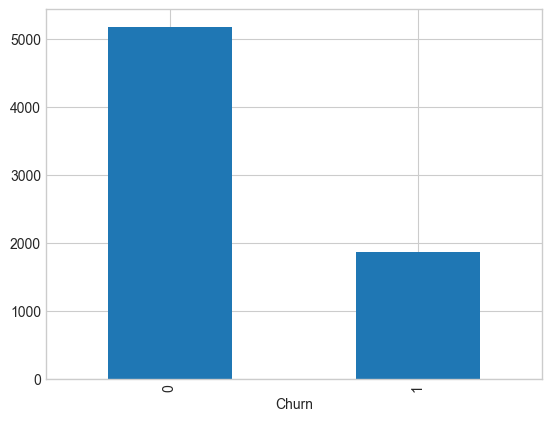

In [9]:
# Bar chart of churn counts (Yes vs No)
df['Churn'].value_counts().plot.bar()


## Who churns? (the segments that matter)

Churn isn't random — it concentrates in clear segments. Highest-risk drivers from the crosstabs below:

| Segment | Churn rate |
|---------|-----------|
| Electronic-check payment | **45%** |
| Month-to-month contract | **43%** |
| Fiber-optic internet | **42%** |
| Senior citizens | **42%** |
| Two-year contract | 3% (most loyal) |

**Retention takeaway:** target month-to-month, fiber, and electronic-check customers first — that's where the churn concentrates.

In [10]:
# Churn RATE by contract type — crosstab normalized across each row
pd.crosstab(df['Contract'], df['Churn'], normalize='index')

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


<Axes: title={'center': 'tenure'}, xlabel='Churn'>

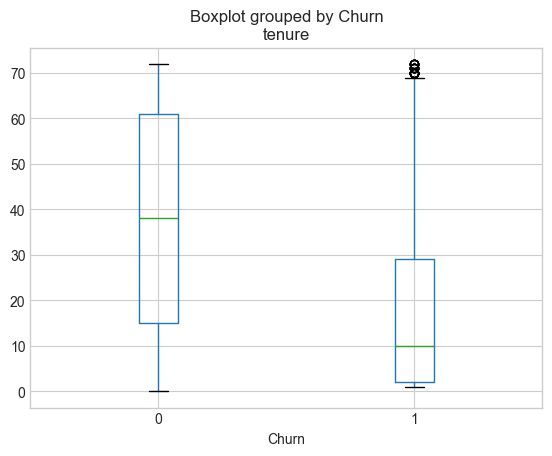

In [11]:
# Does tenure differ for churners vs stayers? Compare the distributions.
df.boxplot(column='tenure', by='Churn')

In [12]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [13]:
pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize ='index')

Churn,0,1
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [14]:
pd.crosstab(df['MultipleLines'],df['Churn'],normalize ='index')


Churn,0,1
MultipleLines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099


In [15]:
pd.crosstab(df['PhoneService'],df['Churn'],normalize ='index')


Churn,0,1
PhoneService,,
No,0.750733,0.249267
Yes,0.732904,0.267096


In [16]:
pd.crosstab(df['InternetService'],df['Churn'],normalize ='index')


Churn,0,1
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [17]:
pd.crosstab(df['PaymentMethod'],df['Churn'],normalize ='index')


Churn,0,1
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


## 5. Prep features

Models need numbers, not text. Two jobs: (a) turn the target into 0/1, (b) one-hot encode the text columns.

In [18]:
# Target → numbers, and drop the ID column (it's not a feature)
df = df.drop(columns='customerID')

In [19]:
# One-hot encode the remaining text columns into 0/1 dummy columns.
# dtype=int makes the DUMMIES 0/1 without touching the continuous columns —
# a blanket .astype(int) here was silently flooring MonthlyCharges / TotalCharges.
df = pd.get_dummies(df, drop_first=True, dtype=int)
df.shape

(7043, 31)

In [20]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


## 6. Train/test split — stratified

**Why `stratify=y`:** with an imbalanced target, a random split could land most churners in one set. Stratifying keeps the ~27% churn ratio identical in train and test.

In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Churn')
y = df['Churn']

# 30% test, stratified so the ~27% churn rate is identical in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]} rows   Test: {X_test.shape[0]} rows")
print(f"Churn rate — train {y_train.mean():.1%} | test {y_test.mean():.1%}")

Train: 4930 rows   Test: 2113 rows
Churn rate — train 26.5% | test 26.5%


## 7. Scale + train Logistic Regression

**Why scale:** logistic regression is sensitive to feature ranges (tenure 0–72 vs TotalCharges 0–8000). Standardize so no feature dominates by size alone. Fit the scaler on **train only**, then apply to test.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_s  = scaler.transform(X_test)        # apply to test — never fit on test

In [23]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)
y_pred = logreg.predict(X_test_s)

## 8. Evaluate — why accuracy lies

**The lesson:** compare your accuracy to the ~73% "predict everyone stays" baseline. Beating it a little isn't enough — you care about *catching churners*. That's **recall** (of the churners, how many did you flag?) and **precision** (of the ones you flagged, how many really churned?).

In [24]:
acc = logreg.score(X_test_s, y_test)
baseline = 1 - y_test.mean()          # "predict everyone stays"

print(f"Model accuracy : {acc:.3f}")
print(f"Lazy baseline  : {baseline:.3f}  (predict 'no churn' for everyone)")
print(f"Lift over lazy : {acc - baseline:+.3f}")

Model accuracy : 0.809
Lazy baseline  : 0.735  (predict 'no churn' for everyone)
Lift over lazy : +0.075


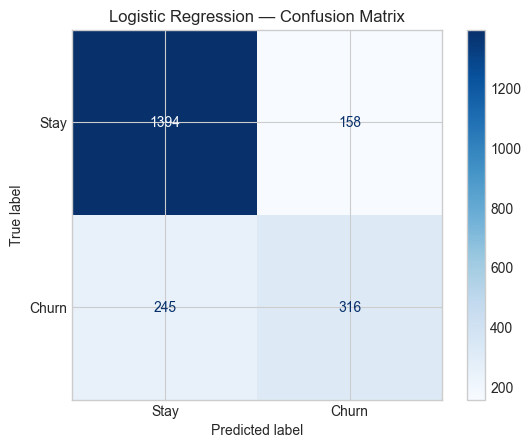

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    logreg, X_test_s, y_test, display_labels=['Stay', 'Churn'], cmap='Blues'
)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))

              precision    recall  f1-score   support

        Stay       0.85      0.90      0.87      1552
       Churn       0.67      0.56      0.61       561

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



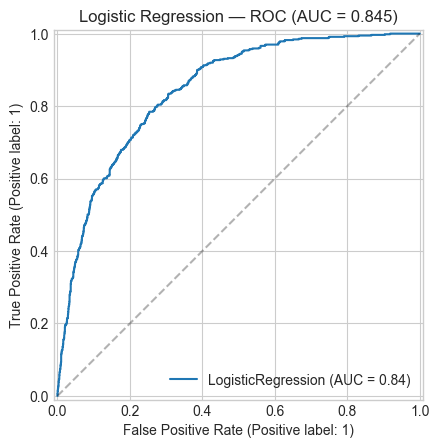

In [27]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

auc = roc_auc_score(y_test, logreg.predict_proba(X_test_s)[:, 1])
RocCurveDisplay.from_estimator(logreg, X_test_s, y_test)
plt.plot([0, 1], [0, 1], 'k--', alpha=.3)
plt.title(f'Logistic Regression — ROC (AUC = {auc:.3f})')
plt.show()

## Improving recall — make the model care about churn

The baseline logistic model misses ~44% of churners. Two standard levers catch more: **`class_weight='balanced'`** (logistic) and **`scale_pos_weight`** (XGBoost), which up-weight the rare churn class. Below — a balanced logistic, a single decision tree, a random forest, and a tuned XGBoost — compared on **churn recall**, not accuracy.

In [28]:
# Same model, but tell it churn matters more → trades precision for higher recall
logreg_bal = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_bal.fit(X_train_s, y_train)

print("Logistic Regression + class_weight='balanced'\n")
print(classification_report(y_test, logreg_bal.predict(X_test_s), target_names=['Stay', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, logreg_bal.predict_proba(X_test_s)[:, 1]):.3f}")

Logistic Regression + class_weight='balanced'

              precision    recall  f1-score   support

        Stay       0.91      0.72      0.81      1552
       Churn       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113

ROC-AUC: 0.844


In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_s, y_train)

print("Decision Tree (single, unpruned)\n")
print(classification_report(y_test, dt.predict(X_test_s), target_names=['Stay', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, dt.predict_proba(X_test_s)[:, 1]):.3f}")

Decision Tree (single, unpruned)

              precision    recall  f1-score   support

        Stay       0.82      0.82      0.82      1552
       Churn       0.50      0.50      0.50       561

    accuracy                           0.73      2113
   macro avg       0.66      0.66      0.66      2113
weighted avg       0.73      0.73      0.73      2113

ROC-AUC: 0.659


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_s, y_train)

print("Random Forest (300 trees)\n")
print(classification_report(y_test, rf.predict(X_test_s), target_names=['Stay', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test_s)[:, 1]):.3f}")

Random Forest (300 trees)

              precision    recall  f1-score   support

        Stay       0.83      0.89      0.86      1552
       Churn       0.62      0.49      0.55       561

    accuracy                           0.79      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.79      0.78      2113

ROC-AUC: 0.822


In [31]:
from xgboost import XGBClassifier

# scale_pos_weight ≈ (stayers / churners) ≈ 2.8 — pushes recall up on the rare churn class
xgb = XGBClassifier(scale_pos_weight=2.8, eval_metric='logloss', random_state=42)
xgb.fit(X_train_s, y_train)

print("XGBoost (scale_pos_weight=2.8)\n")
print(classification_report(y_test, xgb.predict(X_test_s), target_names=['Stay', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb.predict_proba(X_test_s)[:, 1]):.3f}")

XGBoost (scale_pos_weight=2.8)

              precision    recall  f1-score   support

        Stay       0.87      0.78      0.82      1552
       Churn       0.53      0.67      0.59       561

    accuracy                           0.76      2113
   macro avg       0.70      0.73      0.71      2113
weighted avg       0.78      0.76      0.76      2113

ROC-AUC: 0.815


## 9. Compare every model — computed, not asserted

One table, built straight from the fitted models on the held-out test set — including **ROC-AUC** (ranking quality). No hand-typed numbers.

In [32]:
# Single source of truth: metrics pulled from the fitted models, not typed by hand
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

models = {
    'Logistic Regression':            logreg,
    'Logistic Regression (balanced)': logreg_bal,
    'Decision Tree':                  dt,
    'Random Forest':                  rf,
    'XGBoost (scale_pos_weight=2.8)': xgb,
}

comparison = pd.DataFrame({
    name: {
        'Churn precision': precision_score(y_test, m.predict(X_test_s)),
        'Churn recall':    recall_score(y_test, m.predict(X_test_s)),
        'F1':              f1_score(y_test, m.predict(X_test_s)),
        'Accuracy':        accuracy_score(y_test, m.predict(X_test_s)),
        'ROC-AUC':         roc_auc_score(y_test, m.predict_proba(X_test_s)[:, 1]),
    } for name, m in models.items()
}).T.round(3)

comparison

,Churn precision,Churn recall,F1,Accuracy,ROC-AUC
Logistic Regression,0.667,0.563,0.611,0.809,0.845
Logistic Regression (balanced),0.510,0.797,0.622,0.743,0.844
Decision Tree,0.501,0.496,0.498,0.735,0.659
Random Forest,0.621,0.488,0.547,0.785,0.822
XGBoost (scale_pos_weight=2.8),0.531,0.674,0.594,0.755,0.815


In [33]:
# Does the ranking survive beyond one split? 5-fold stratified CV on ROC-AUC.
# The scaler is fit INSIDE each fold (pipeline) so there's no leakage.
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=300, random_state=42),
    'XGBoost':             XGBClassifier(scale_pos_weight=2.8, eval_metric='logloss', random_state=42),
}
for name, m in cv_models.items():
    s = cross_val_score(make_pipeline(StandardScaler(), m), X, y, cv=cv, scoring='roc_auc')
    print(f"{name:22s} AUC {s.mean():.3f} ± {s.std():.3f}")

Logistic Regression    AUC 0.845 ± 0.013


Random Forest          AUC 0.825 ± 0.012


XGBoost                AUC 0.822 ± 0.011


## 10. The real lever — pick the threshold that maximizes ROI

The model only **ranks** customers; the business decides **where to cut**. Sweep the decision threshold and choose the point that maximizes expected campaign value:

> **Net value = (churners caught × value of a save) − (everyone flagged × cost of an offer)**

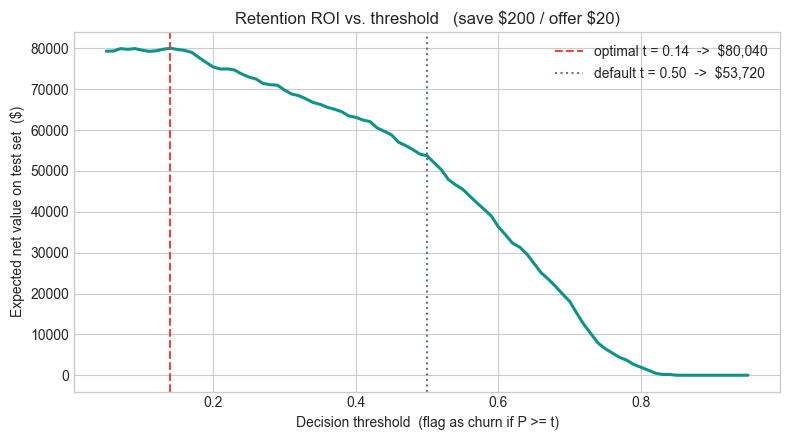

Value-maximizing threshold : 0.14   (net $80,040)
Naive 0.50 threshold       : net $53,720
Value left on the table by not tuning the cut: $26,320


In [34]:
# Economics — stated assumptions; swap in real offer numbers:
VALUE_OF_SAVE = 200   # margin ($) preserved when we catch & retain a would-be churner
OFFER_COST    = 20    # cost ($) of the retention offer, paid to EVERYONE we flag

proba = logreg.predict_proba(X_test_s)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)

net = np.array([
    ((y_test == 1) & (proba >= t)).sum() * VALUE_OF_SAVE
    - (proba >= t).sum() * OFFER_COST          # offer cost on every flagged customer
    for t in thresholds
])

best_i    = net.argmax()
best_t    = thresholds[best_i]
default_v = net[np.argmin(np.abs(thresholds - 0.50))]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, net, lw=2.2, color='#0d9488')
ax.axvline(best_t, ls='--', color='#ef4444',
           label=rf'optimal t = {best_t:.2f}  ->  \${net[best_i]:,.0f}')
ax.axvline(0.50, ls=':', color='#64748b',
           label=rf'default t = 0.50  ->  \${default_v:,.0f}')
ax.set(xlabel='Decision threshold  (flag as churn if P >= t)',
       ylabel=r'Expected net value on test set  (\$)',
       title=rf'Retention ROI vs. threshold   (save \${VALUE_OF_SAVE} / offer \${OFFER_COST})')
ax.legend(); fig.tight_layout()

import os; os.makedirs('../assets', exist_ok=True)
fig.savefig('../assets/threshold_roi.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Value-maximizing threshold : {best_t:.2f}   (net ${net[best_i]:,.0f})")
print(f"Naive 0.50 threshold       : net ${default_v:,.0f}")
print(f"Value left on the table by not tuning the cut: ${net[best_i] - default_v:,.0f}")

## Results & Recommendation

**Model comparison** (test set = 2,113 customers; *churn* is the positive class). Numbers are computed in the cell above — not hand-typed:

| Model | Churn precision | Churn recall | F1 | Accuracy | ROC-AUC |
|-------|:---:|:---:|:---:|:---:|:---:|
| Logistic Regression | 0.67 | 0.56 | 0.61 | 0.81 | 0.845 |
| Logistic Regression (balanced) | 0.51 | **0.80** | 0.62 | 0.74 | 0.844 |
| Decision Tree (single, unpruned) | 0.50 | 0.50 | 0.50 | 0.73 | 0.659 |
| Random Forest | 0.62 | 0.49 | 0.55 | 0.79 | 0.822 |
| **XGBoost (`scale_pos_weight=2.8`)** | 0.53 | **0.67** | 0.59 | 0.76 | 0.815 |

*5-fold stratified CV confirms the ranking is stable: Logistic Regression 0.845 ± 0.013, Random Forest 0.825 ± 0.012, XGBoost 0.822 ± 0.011.*

**What this says**
- **Accuracy is a trap here.** A do-nothing "predict everyone stays" model already scores ~73%. The honest question is *how many churners do we catch* — that's **recall**.
- **Ranking vs. deciding are different jobs.** The strong models rank churners similarly (AUC ≈ 0.82–0.85); the lone exception is a single unpruned Decision Tree (0.66) — which is exactly why we reach for ensembles and regularized models. What changes the catch-rate is the **decision threshold / class weighting**, not a fancier algorithm.
- **Raising recall costs precision.** Tuning `scale_pos_weight` / `class_weight` slides *along* that trade-off — catch more churners, accept more false alarms. It doesn't lift the whole curve.

### The decision is the threshold — and it's worth real money

![Retention ROI vs. threshold](../assets/threshold_roi.png)

At **$200 per save / $20 per offer**, the value-maximizing cutoff is **t ≈ 0.14**, not the default 0.50 — worth **+$26,320** of expected net value on the 2,113-customer test set (**$80,040 vs. $53,720**). Same model, same data; the only thing that changed is *where we drew the line*.

**Recommendation — the model choice is a business decision, not a modeling one.** Pick the operating point that maximizes expected value:

> **Net value = (churners caught × value of a save) − (everyone flagged × cost of an offer)**

When a saved customer is worth far more than a wasted offer, lean toward **high recall** (balanced logistic, or XGBoost with a higher `scale_pos_weight`) and a **lower threshold**. When retention offers are expensive, tighten precision and raise the cut. Either way: the model **ranks** customers; the **business sets the cutoff**.

**Next steps:** add behavioral features (recent usage drop, support tickets, tenure milestones), **calibrate** the probabilities so the dollar curve reflects true risk, and validate the chosen threshold against real offer economics.